Data Understanding & Cleaning

Load Dataset

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("employee_attrition_dataset.csv")

print(df.shape)
print(df.head())

(6786, 35)
   Employee_ID   Age Gender Marital_Status Education_Level Field_of_Study  \
0            1  56.0   Male        Married             PhD        Science   
1            2  46.0   Male         Single        Master's        Science   
2            3  32.0  Other       Divorced         Diploma             IT   
3            4  60.0  Other         Single        Master's             IT   
4            5  25.0   Male       Divorced      Bachelor's    Engineering   

  Department    Job_Role  Job_Level Employment_Type  ... Remote_Work  \
0      Sales     Manager        2.0        Contract  ...          No   
1         HR   Executive        1.0       Full-time  ...          No   
2         IT  Consultant        1.0        Contract  ...          No   
3         IT   Developer        4.0        Contract  ...          No   
4         IT   Developer        1.0       Part-time  ...          No   

   Distance_From_Home  Absenteeism_Days  Projects_Handled  Manager_Rating  \
0               

Data Cleaning

In [ ]:
# Missing Values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Final Shape:", df.shape)

Employee_ID                      0
Age                              1
Gender                           1
Marital_Status                   1
Education_Level                  1
Field_of_Study                   1
Department                       1
Job_Role                         1
Job_Level                        1
Employment_Type                  1
Hire_Date                        1
Years_at_Company                 1
Years_in_Current_Role            1
Years_Since_Last_Promotion       1
Monthly_Income                   1
Annual_Bonus                     1
Stock_Option_Level               1
Performance_Rating               1
Job_Satisfaction                 1
Environment_Satisfaction         1
Relationship_Satisfaction        1
Work_Life_Balance                1
Training_Hours_Last_Year         1
Overtime                         1
Business_Travel               2221
Remote_Work                      1
Distance_From_Home               1
Absenteeism_Days                 1
Projects_Handled    

Create Derived Columns

Salary Band

In [ ]:
df['Salary_Band'] = pd.cut(
    df['Monthly_Income'],
    bins=[0,5000,10000,20000],
    labels=['Low','Medium','High']
)

Experience Group

In [ ]:
df['Experience_Group'] = pd.cut(
    df['Years_at_Company'],
    bins=[0,3,7,50],
    labels=['Fresher','Mid-Level','Senior']
)

High Risk Employees

In [ ]:
df['Risk_Category'] = np.where(
    df['Attrition_Risk_Score'] > 70,
    'High Risk',
    'Low Risk'
)

Phase 2: KPI Design   

Total Employees

In [ ]:
total_emp = len(df)

print("Total Employees:", total_emp)

Total Employees: 6786


Attrition Rate

In [ ]:
attrition_rate = (
    (df['Attrition'] == 'Yes').mean()
) * 100

print("Attrition Rate:", round(attrition_rate,2))

Attrition Rate: 81.87


Retention Rate

In [ ]:
retention_rate = 100 - attrition_rate

print("Retention Rate:", round(retention_rate,2))

Retention Rate: 18.13


Average Tenure

In [ ]:
avg_tenure = df['Years_at_Company'].mean()

print("Average Tenure:", round(avg_tenure,2))

Average Tenure: 20.08


Average Income

In [ ]:
avg_income = df['Monthly_Income'].mean()

print("Average Income:", round(avg_income,2))

Average Income: 109589.18


Job Satisfaction

In [ ]:
job_sat = df['Job_Satisfaction'].mean()

print("Job Satisfaction:", round(job_sat,2))

Job Satisfaction: 3.0


Overtime Percentage

In [ ]:
overtime_pct = (
    (df['Overtime'] == 'Yes').mean()
) * 100

print("Overtime %:", round(overtime_pct,2))

Overtime %: 50.87


High Risk Employees

In [ ]:
high_risk = (
    df['Risk_Category'] == 'High Risk'
).sum()

print("High Risk Employees:", high_risk)

High Risk Employees: 3937


Phase 3: Analytics Investigation  

Department vs Attrition

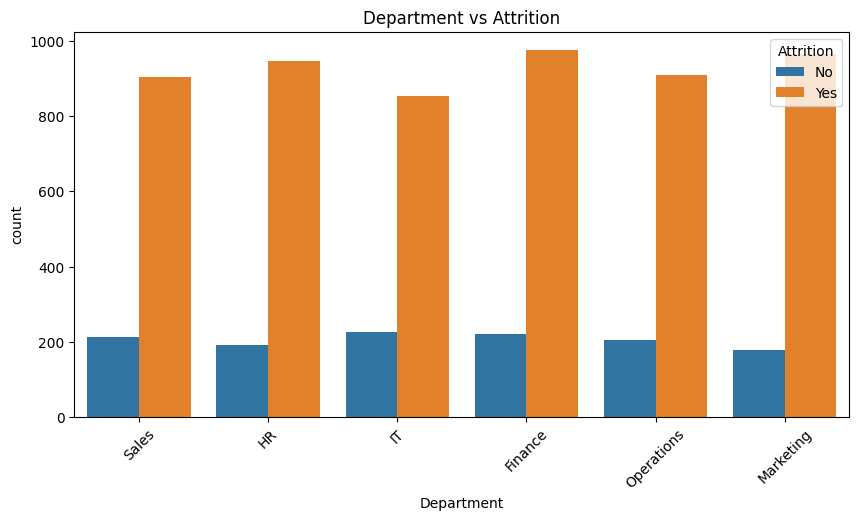

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Department',
    hue='Attrition'
)

plt.xticks(rotation=45)
plt.title("Department vs Attrition")
plt.show()

Salary vs Attrition

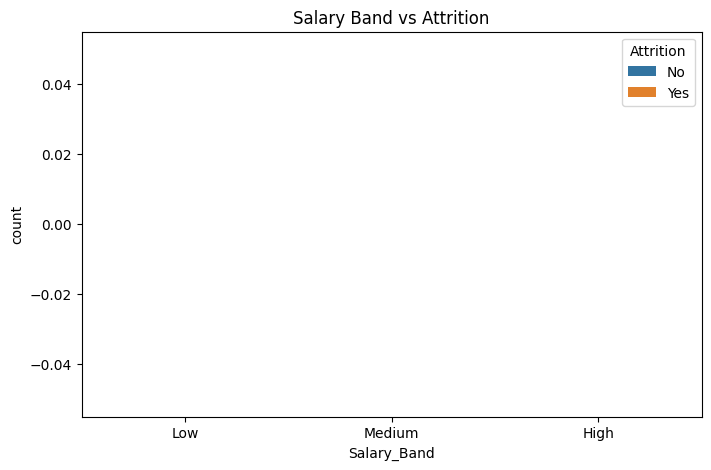

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Salary_Band',
    hue='Attrition'
)

plt.title("Salary Band vs Attrition")
plt.show()

Work Life Balance vs Attrition

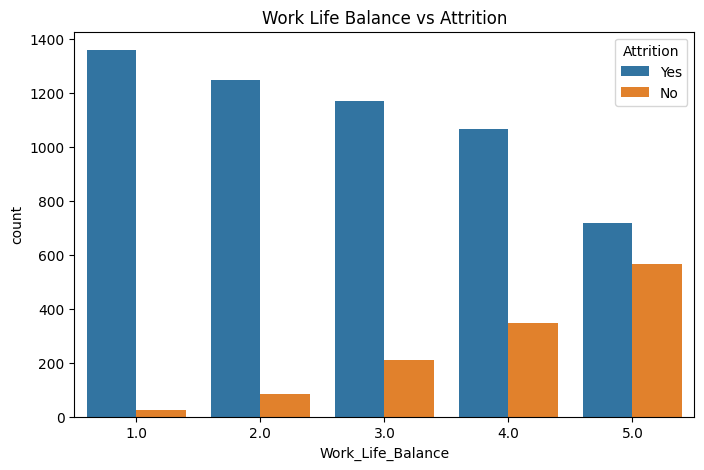

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Work_Life_Balance',
    hue='Attrition'
)

plt.title("Work Life Balance vs Attrition")
plt.show()

Overtime vs Attrition

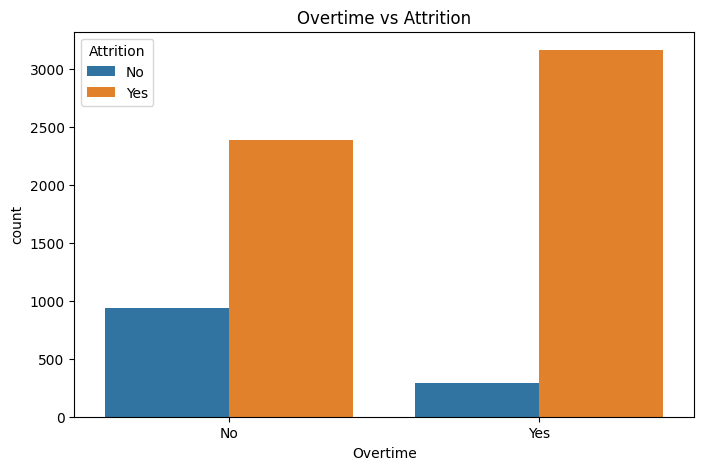

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Overtime',
    hue='Attrition'
)

plt.title("Overtime vs Attrition")
plt.show()

Job Satisfaction vs Attrition

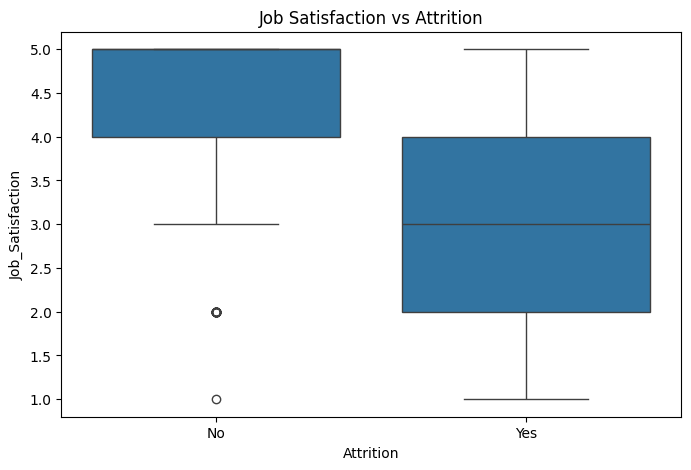

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='Job_Satisfaction'
)

plt.title("Job Satisfaction vs Attrition")
plt.show()

Correlation Heatmap

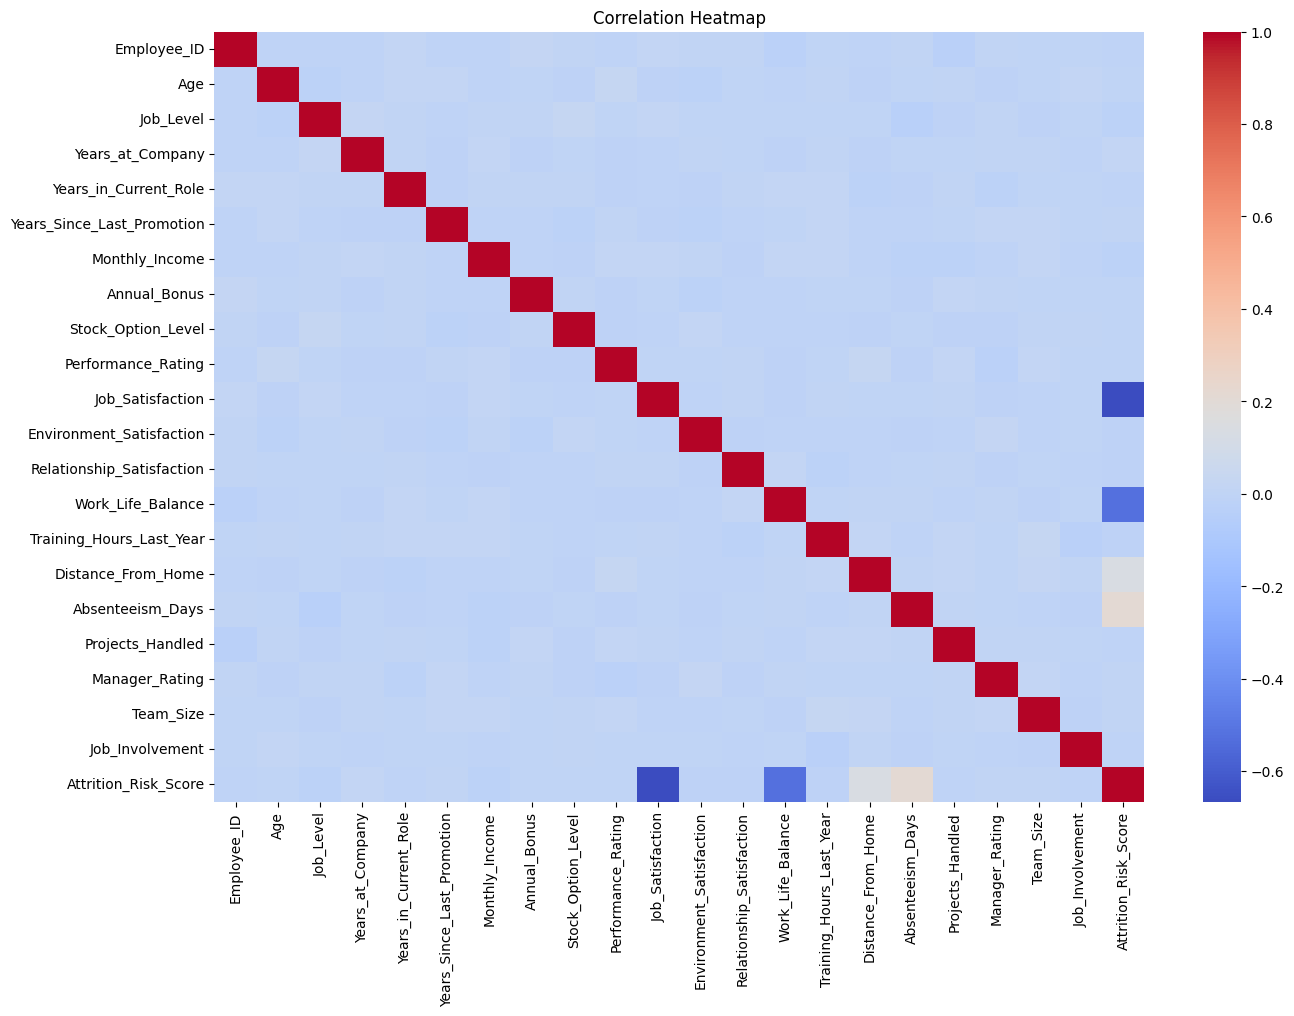

In [ ]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(15,10))

sns.heatmap(
    numeric_cols.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Phase 4: Employee Segmentation  

High Risk

In [ ]:
high_risk = df[
    df['Risk_Category'] == 'High Risk'
]

Long-Term Employees

In [ ]:
long_term = df[
    df['Years_at_Company'] > 10
]

Overtime Employees

In [ ]:
overtime_emp = df[
    df['Overtime'] == 'Yes'
]

Dissatisfied Employees

In [ ]:
dissatisfied = df[
    df['Job_Satisfaction'] <= 2
]